# Verifying predicted drug–disease pairs

Picks up directly from your fitted model — `prob_full`, `Y`, `drugs_features`,
`diseases_features` — and checks the top-ranked originally-zero pairs against
independent evidence.

| source | what it is | strength |
|---|---|---|
| **CTD** `DirectEvidence = therapeutic` | manually curated drug→disease treatment records | primary — DRIMC's criterion |
| **ChEMBL** `drug_indication` | indication + max clinical phase | strong, adds phase 1–4 |
| **PubMed** co-occurrence | title/abstract hits | weak — triage only |

**Two changes from your snippet, both deliberate:**

1. **Per-drug top-N, not global top-K.** `np.argsort(-zero_probs)[:10]` takes the ten
   highest scores in the *whole matrix*. Those tend to concentrate on a few well-connected
   drugs — you can easily get all ten from one or two drugs, and the ranking is dominated
   by row/column degree. Hit rates in this literature are *per drug* ("13.11% of drugs have
   an indication in their top 5"), so you need each drug's own top-N. Both modes are below;
   global is kept for reference.
2. **ID mapping on both axes.** CTD keys chemicals by MeSH, not DrugBank, and it curates
   diseases by MeSH while Cdataset labels them with OMIM numbers. Sections 3a and 4 handle
   both, and report what resolved rather than failing silently.

Run Sections 1–2 once per kernel. Section 4 needs a human pass. Sections 5–8 are results.

## 0. Run the models for the entire dataset

### Import dataset

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

PATH_ROOT = "/Users/sijianfan/projects/BiSSGL"
PATH_TO_EXP = os.path.join(PATH_ROOT, "datasets/realAnalysis/cdataset")
PATH_DATA = os.path.join(PATH_TO_EXP, "cv_data")
FIG_DIR = os.path.join(PATH_ROOT, "outputs/figures/realAnalysis/cdataset/fold_cv/comb")
TAB_DIR = os.path.join(PATH_ROOT, "outputs/tables/realAnalysis/cdataset/fold_cv/comb")
DATASET = "cdataset"
if not os.path.isdir(PATH_DATA):
    os.mkdir(PATH_DATA)

# The adjacency matrix of the drug-disease association network, with drugs as rows and diseases as columns.
df_Y = pd.read_table(os.path.join(PATH_TO_EXP, "c_admat_dgc.txt"), index_col=0).T
print("Shape of df_Y:", df_Y.shape)

# The feature matrices of drugs
drugs_features = pd.read_csv(
    os.path.join(PATH_TO_EXP, "drugs_features.csv"), index_col=0
)
print("Shape of drugs_features:", drugs_features.shape)
print("First 5 rows of drugs_features:")
print(drugs_features.head().iloc[:, :3])

# The feature matrices of diseases
diseases_features = pd.read_csv(
    os.path.join(PATH_TO_EXP, "diseases_features.csv"), index_col=0
)
print("Shape of diseases_features:", diseases_features.shape)
print("First 5 rows of diseases_features:")
print(diseases_features.head().iloc[:, :3])

Shape of df_Y: (658, 409)
Shape of drugs_features: (658, 1888)
First 5 rows of drugs_features:
         ECFP_0  ECFP_1  ECFP_2
DB00014       0       1       0
DB00035       0       1       0
DB00091       0       1       0
DB00104       0       0       0
DB00115       1       1       0
Shape of diseases_features: (409, 797)
First 5 rows of diseases_features:
         HPO_HP:0000006  HPO_HP:0000707  HPO_HP:0012638
D102100               1               0               0
D102300               1               1               1
D102400               1               0               0
D102500               1               1               1
D103100               1               1               1


In [2]:
from sgimc.utils import load
import numpy as np

filename_input = os.path.join(PATH_DATA, "staged_dataset.gz")
U, V, Y_signed = load(filename_input)
U = np.asarray(U.toarray() if hasattr(U, "toarray") else U, dtype=float)
V = np.asarray(V.toarray() if hasattr(V, "toarray") else V, dtype=float)
n_orig_U, n_orig_V = U.shape[1], V.shape[1]
U_orig, V_orig = U.copy(), V.copy()
U = np.concatenate([U, np.eye(U.shape[0])], axis=1)
V = np.concatenate([V, np.eye(V.shape[0])], axis=1)
print(
    f"Augmented U: {U.shape[0]}, {n_orig_U} → {U.shape[1]},  V: {V.shape[0]}, {n_orig_V} → {V.shape[1]}"
)
Y = (Y_signed > 0).astype(int)

Augmented U: 658, 1888 → 2546,  V: 409, 797 → 1206


### SGIMC

In [3]:
from sgimc import SparseGroupIMCClassifier
from scipy.sparse import coo_matrix

Y_signed_sp = coo_matrix(Y_signed)

In [4]:
C_lasso = 0.01
C_group = 1.0
C_ridge = 1.0
rank = 50

# SGIMC can directly uses {-1, +1} encoding: 1→+1, 0→-1
sgimc = SparseGroupIMCClassifier(
    rank,
    n_threads=-1,
    random_state=2026,
    C_lasso=C_lasso,
    C_group=C_group,
    C_ridge=C_ridge,
)
sgimc.fit(U, V, Y_signed_sp.tocsr())
prob_full_sgimc = sgimc.predict_proba(U, V)

### IMC

In [5]:
C_lasso = 0.0
C_group = 0.0
C_ridge = 1.0
lamb = 0.1
rank = 50

imc = SparseGroupIMCClassifier(
    rank,
    n_threads=-1,
    random_state=2026,
    C_lasso=C_lasso,
    C_group=C_group,
    C_ridge=C_ridge,
)
imc.fit(U, V, Y_signed_sp, sample_weight=np.ones(Y_signed_sp.nnz) / lamb)
prob_full_imc = imc.predict_proba(U, V)

### BiSSGL

In [6]:
import sys

sys.path.append(PATH_ROOT)
from scripts.methods.BiSSGL.BiSSGLc import BiSSGL
from scipy.special import expit

In [7]:
bissgl = BiSSGL(
    Y=Y,
    U=U,
    V=V,
    xi=5,
    eta=5e-7,
    tilde_lambda0=15,
    tilde_lambda1=1,
    tilde_alpha=1 / 200 / 600,
    tilde_beta=1,
    lambda0=15,
    lambda1=1,
    alpha=1 / 200 / 400,
    beta=1,
    K=200,
    max_iter=1000,
    tol=1e-8,
)

# fit on the whole development dataset
_, est_A, est_B, logLik = bissgl.optimization()
prob_full_bissgl = expit(U @ est_A @ est_B.T @ V.T)

Finished with iterations of 999


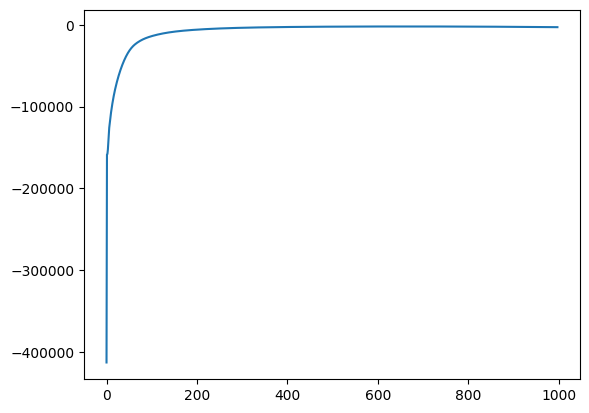

In [8]:
plt.plot(logLik)

In [ ]:
import numpy as np
from scipy.special import expit

# predicted probability matrix
prob_full = expit(U @ est_A @ est_B.T @ V.T)

# mask for Y == 0
zero_mask = Y == 0

# extract probabilities where Y == 0
zero_probs = prob_full[zero_mask]

# get indices (row, col) of those entries
zero_indices = np.argwhere(zero_mask)

# sort descending by probability
top_k = 10
top_order = np.argsort(-zero_probs)[:top_k]

top_probs = zero_probs[top_order]
top_positions = zero_indices[top_order]

# report
for i in range(top_k):
    r, c = top_positions[i]
    print(f"Rank {i+1}: index=({r}, {c}), predicted_prob={top_probs[i]:.6f}")

Rank 1: index=(265, 38), predicted_prob=0.985958
Rank 2: index=(467, 104), predicted_prob=0.983497
Rank 3: index=(459, 104), predicted_prob=0.980030
Rank 4: index=(238, 104), predicted_prob=0.974086
Rank 5: index=(292, 377), predicted_prob=0.968027
Rank 6: index=(292, 380), predicted_prob=0.968027
Rank 7: index=(436, 38), predicted_prob=0.954201
Rank 8: index=(584, 100), predicted_prob=0.949681
Rank 9: index=(384, 38), predicted_prob=0.942539
Rank 10: index=(101, 380), predicted_prob=0.942108


In [ ]:
import numpy as np
from scipy.special import expit

# predicted probability matrix
prob_full = expit(U @ est_A @ est_B.T @ V.T)

# mask where Y == 0
zero_mask = Y == 0

# probabilities at Y == 0
zero_probs = prob_full[zero_mask]

# positions (row, col) where Y == 0
zero_indices = np.argwhere(zero_mask)

# top 10 highest predicted probabilities
top_k = 10
top_order = np.argsort(-zero_probs)[:top_k]

top_probs = zero_probs[top_order]
top_positions = zero_indices[top_order]

# report using names
for i in range(top_k):
    r, c = top_positions[i]
    drug_name = drugs_features.index[r]
    disease_name = diseases_features.index[c]

    print(
        f"Rank {i+1}: "
        f"Drug = {drug_name}, "
        f"Disease = {disease_name}, "
        f"Predicted probability = {top_probs[i]:.6f}"
    )

Rank 1: Drug = DB00620, Disease = D125600, Predicted probability = 0.985958
Rank 2: Drug = DB01008, Disease = D151380, Predicted probability = 0.983497
Rank 3: Drug = DB00997, Disease = D151380, Predicted probability = 0.980030
Rank 4: Drug = DB00563, Disease = D151380, Predicted probability = 0.974086
Rank 5: Drug = DB00669, Disease = D607498, Predicted probability = 0.968027
Rank 6: Drug = DB00669, Disease = D607508, Predicted probability = 0.968027
Rank 7: Drug = DB00959, Disease = D125600, Predicted probability = 0.954201
Rank 8: Drug = DB01234, Disease = D147540, Predicted probability = 0.949681
Rank 9: Drug = DB00860, Disease = D125600, Predicted probability = 0.942539
Rank 10: Drug = DB00320, Disease = D607508, Predicted probability = 0.942108


In [ ]:
model = BiSSGL(
    Y=Y,
    U=U,
    V=V,
    xi=3,
    eta=5e-7,
    tilde_lambda0=25,
    tilde_lambda1=1,
    tilde_alpha=1 / 200 / 5000,
    tilde_beta=1,
    lambda0=25,
    lambda1=1,
    alpha=1 / 200 / 1000,
    beta=1,
    K=50,
    max_iter=5000,
    tol=1e-10,
)

# fit on the whole development dataset
est_mu, est_A, est_B, logLik = model.optimization()

In [14]:
import numpy as np
from scipy.special import expit

# predicted probability matrix
prob_full = expit(U @ est_A @ est_B.T @ V.T)

# mask for Y == 0
zero_mask = Y == 0

# extract probabilities where Y == 0
zero_probs = prob_full[zero_mask]

# get indices (row, col) of those entries
zero_indices = np.argwhere(zero_mask)

# sort descending by probability
top_k = 10
top_order = np.argsort(-zero_probs)[:top_k]

top_probs = zero_probs[top_order]
top_positions = zero_indices[top_order]

# report
for i in range(top_k):
    r, c = top_positions[i]
    print(f"Rank {i+1}: index=({r}, {c}), predicted_prob={top_probs[i]:.6f}")
import numpy as np
from scipy.special import expit

# predicted probability matrix
prob_full = expit(U @ est_A @ est_B.T @ V.T)

# mask where Y == 0
zero_mask = Y == 0

# probabilities at Y == 0
zero_probs = prob_full[zero_mask]

# positions (row, col) where Y == 0
zero_indices = np.argwhere(zero_mask)

# top 10 highest predicted probabilities
top_k = 10
top_order = np.argsort(-zero_probs)[:top_k]

top_probs = zero_probs[top_order]
top_positions = zero_indices[top_order]

# report using names
for i in range(top_k):
    r, c = top_positions[i]
    drug_name = drugs_features.index[r]
    disease_name = diseases_features.index[c]

    print(
        f"Rank {i+1}: "
        f"Drug = {drug_name}, "
        f"Disease = {disease_name}, "
        f"Predicted probability = {top_probs[i]:.6f}"
    )

Rank 1: index=(265, 38), predicted_prob=0.936873
Rank 2: index=(100, 99), predicted_prob=0.901136
Rank 3: index=(173, 222), predicted_prob=0.824453
Rank 4: index=(290, 222), predicted_prob=0.804877
Rank 5: index=(308, 99), predicted_prob=0.788718
Rank 6: index=(155, 359), predicted_prob=0.752510
Rank 7: index=(155, 358), predicted_prob=0.735021
Rank 8: index=(155, 362), predicted_prob=0.732897
Rank 9: index=(303, 345), predicted_prob=0.703966
Rank 10: index=(436, 38), predicted_prob=0.689896
Rank 1: Drug = DB00620, Disease = D125600, Predicted probability = 0.936873
Rank 2: Drug = DB00318, Disease = D147530, Predicted probability = 0.901136
Rank 3: Drug = DB00443, Disease = D233810, Predicted probability = 0.824453
Rank 4: Drug = DB00663, Disease = D233810, Predicted probability = 0.804877
Rank 5: Drug = DB00704, Disease = D147530, Predicted probability = 0.788718
Rank 6: Drug = DB00405, Disease = D605805, Predicted probability = 0.752510
Rank 7: Drug = DB00405, Disease = D605804, Pred

### DRIMC

In [9]:
from sklearn.metrics import pairwise_distances
import rpy2.robjects as robjects

r = robjects.r
DRIMC_PATH = os.path.join(PATH_ROOT, "scripts/methods/DRIMC")
r(f'setwd("{DRIMC_PATH}")')

# attach R packages
for pkg in ["matrixcalc", "data.table", "Rcpp", "ROCR", "Bolstad2", "MESS"]:
    r(f"library({pkg})")

# source R helper files (only what's needed)
for r_file in [
    "constrNeig.R",
    "calcLogLik.R",
    "calcDeriv.R",
    "updateUV.R",
]:
    r(f'source("{r_file}")')

# source C++ extensions needed by updateUV
r("library(Rcpp)")
for cpp_file in ["log1pexp.cpp", "sigmoid.cpp"]:
    r(f'sourceCpp("{cpp_file}")')

# bind R functions to Python
updateUV_R = r["updateUV"]
constrNeig_R = r["constrNeig"]


# ====== helpers ======
def to_r_matrix(arr):
    return r.matrix(
        robjects.FloatVector(arr.flatten()),
        byrow=True,
        nrow=arr.shape[0],
        ncol=arr.shape[1],
    )


# ====== build similarity matrices (Jaccard, computed once) ======
simD = 1 - pairwise_distances(U_orig, metric="cosine")
simT = 1 - pairwise_distances(V_orig, metric="cosine")

# handle NaN from all-zero rows (Jaccard is undefined → set self-sim = 1, rest = 0)
simD = np.nan_to_num(simD, nan=0.0)
simT = np.nan_to_num(simT, nan=0.0)
np.fill_diagonal(simD, 1.0)
np.fill_diagonal(simT, 1.0)

print("simD: %s,  simT: %s", simD.shape, simT.shape)

# apply neighbourhood constraint via constrNeig
K_neig = 20
simD_Robj = to_r_matrix(simD)
simT_Robj = to_r_matrix(simT)
Y_Robj = to_r_matrix(Y)
lap = constrNeig_R(simD_Robj, simT_Robj, K=K_neig)
simD_R = lap.rx2("simD")
simT_R = lap.rx2("simT")
simD_np = np.array(simD_R)
simT_np = np.array(simT_R)

R callback write-console: data.table 1.17.8 using 6 threads (see ?getDTthreads).    
R callback write-console: Latest news: r-datatable.com
  


simD: %s,  simT: %s (658, 658) (409, 409)


In [10]:
# print(collected["drimc"]["best_params"])
# trial  fold  lamU  lamV  cc  iterpara  numLat  val_score_f1  n_inner_cv
# 0       0     0     4     2  10     0.125     200      0.166531           3
drimc = updateUV_R(
    cc=10,
    inMat=Y_Robj,
    Sd=simD_R,
    St=simT_R,
    lamU=4,
    lamV=2,
    numLat=200,
    initMethod="useSeed",
    thisSeed=2026,
    iterpara=0.125,
    maxIter=100,
)
est_U = np.array(drimc.rx2("U"))
est_V = np.array(drimc.rx2("V"))

# predict: simD @ est_U @ (simT @ est_V).T → sigmoid
SA = simD_np @ est_U
STB = simT_np @ est_V
prob_full_drimc = expit(SA @ STB.T)

### NRLMF

In [11]:
from PyDTI3.nrlmf import NRLMF

In [12]:
K_neig = 5
lap = constrNeig_R(simD_Robj, simT_Robj, K=K_neig)
simD_R = lap.rx2("simD")
simT_R = lap.rx2("simT")
simD_np = np.array(simD_R)
simT_np = np.array(simT_R)

In [13]:
nrlmf = NRLMF(
    cfix=10,
    K1=5,
    K2=5,
    num_factors=50,
    lambda_d=1.0,
    lambda_t=1.0,
    alpha=0.25,
    beta=0.125,
    theta=0.5,
    max_iter=100,
)
# NRLMF uses 0/1 encoding
nrlmf.fix_model(np.ones_like(Y), Y, simD_np, simT_np)
# nrlmf.fix_model(np.ones_like(Y), Y, np.eye(Y.shape[0]), np.eye(Y.shape[1]))
est_A, est_B = nrlmf.U, nrlmf.V

# predict: simD @ est_A @ est_B.T @ simT.T → sigmoid
prob_full_nrlmf = expit(simD_np @ est_A @ est_B.T @ simT_np.T)
# prob_full_nrlmf = expit(est_A @ est_B.T)

---

In [20]:
%load_ext autoreload
%autoreload 2

## 1. Setup

`verify_predictions.py` must sit next to this notebook.

In [14]:
import os, sys, re, time, importlib
import numpy as np
import pandas as pd
from scipy.special import expit

sys.path.insert(0, os.getcwd())
import scripts.methods.BiSSGL.utils_verify as vp

importlib.reload(vp)

# Anchor paths on the project root so this works whether the notebook sits at
# BiSSGL/ or BiSSGL/scripts/.
ROOT = os.path.abspath(os.getcwd())
while (
    not os.path.isdir(os.path.join(ROOT, "datasets")) and os.path.dirname(ROOT) != ROOT
):
    ROOT = os.path.dirname(ROOT)
DATA_DIR = os.path.join(ROOT, "datasets", "realAnalysis", "cdataset")
print("project root:", ROOT)

# CTD bulk files live OUTSIDE the project (~2 GB, re-downloadable).
vp.CACHE = os.environ.setdefault(
    "VERIFY_CACHE", os.path.expanduser("~/.cache/drug_verify")
)
print("cache dir:", vp.CACHE)

project root: /Users/sijianfan/projects/BiSSGL
cache dir: /Users/sijianfan/.cache/drug_verify


### 1a. Download CTD bulk files — run once (a few minutes)

In [15]:
if not os.path.exists(os.path.join(vp.CACHE, "CTD_chemicals_diseases.tsv.gz")):
    vp.cmd_cache(None)
else:
    print("already cached\n")
    print(open(os.path.join(vp.CACHE, "PROVENANCE.txt")).read()[:500])

already cached

# cache built 2026-08-25 14:12:06 EDT

source : https://ctdbase.org/reports/CTD_chemicals_diseases.tsv.gz
file   : CTD_chemicals_diseases.tsv.gz
bytes  : 161580117
mtime  : 2026-08-25 14:11:43
  # The Comparative Toxicogenomics Database (CTD) - http://ctdbase.org/
  #   Copyright 2002-2012 MDI Biological Laboratory. All rights reserved.
  #   Copyright 2012-2026 NC State University. All rights reserved.
  #  
  # 
  # Use is subject to the terms set forth at http://ctdbase.org/about/legal.jsp
  


## 2. Load CTD indexes — run once per kernel

The slow cell (~30 s, ~2 GB RAM). Everything after it is instant, which is the whole
reason to do this in a notebook rather than a script.

In [16]:
%%time
CTD       = vp.load_ctd_therapeutic()     # (mesh_chem, disease) -> evidence, PMIDs
CHEM_NAME = vp.load_ctd_chem_names()      # normalised name -> MeSH chemical ID
CHEM_CAS  = vp.load_ctd_chem_cas()        # CAS number     -> MeSH chemical ID
CHEM_LOOSE= vp.load_ctd_chem_names(loose=True)   # salt-stripped CTD names
DIS_NAME  = vp.load_ctd_disease_names()   # normalised name -> MeSH disease ID
TREE      = vp.load_disease_tree()        # MeSH disease ID -> tree numbers
OMIM_MAP  = vp.load_ctd_omim_map()        # OMIM number    -> CTD disease ID (xref)

print(f"{len(CTD):,} curated pairs | {len(CHEM_NAME):,} chem names | "
      f"{len(CHEM_CAS):,} CAS | {len(OMIM_MAP):,} OMIM refs")

[ctd] 109591 curated direct-evidence chemical-disease rows
[ctd] 178158 chemical name keys
[ctd] 56619 CAS numbers
[ctd] 177246 chemical salt-stripped name keys
[ctd] 80146 disease name/synonym keys


105,764 curated pairs | 178,158 chem names | 56,619 CAS | 5,618 OMIM refs
CPU times: user 10.4 s, sys: 118 ms, total: 10.6 s
Wall time: 10.6 s


[ctd] 5618 OMIM cross-references


## 3. Extract candidate pairs from your fitted model

Assumes `prob_full`, `Y`, `drugs_features`, `diseases_features` are already in memory.
If the kernel was restarted, re-run your fitting cells first.

In [17]:
# Recompute if needed (your code):
prob_full = prob_full_bissgl
# prob_full = prob_full_sgimc
# prob_full = prob_full_imc
# prob_full = prob_full_drimc
# prob_full = prob_full_nrlmf

drug_ids = np.asarray(drugs_features.index).astype(str)
disease_ids = np.asarray(diseases_features.index).astype(str)
Y_arr = np.asarray(Y)

assert prob_full.shape == Y_arr.shape, (prob_full.shape, Y_arr.shape)
assert len(drug_ids) == Y_arr.shape[0], (len(drug_ids), Y_arr.shape)
assert len(disease_ids) == Y_arr.shape[1], (len(disease_ids), Y_arr.shape)

print(f"{Y_arr.shape[0]} drugs x {Y_arr.shape[1]} diseases")
print(
    f"{int(Y_arr.sum())} known associations, "
    f"{int((Y_arr == 0).sum()):,} zero entries"
)
print("drug index  :", drug_ids[:3])
print("disease index:", disease_ids[:3])

658 drugs x 409 diseases
2520 known associations, 266,602 zero entries
drug index  : ['DB00014' 'DB00035' 'DB00091']
disease index: ['D102100' 'D102300' 'D102400']


### 3a. What kind of labels are on the axes?

**The disease axis is the dangerous one.** Cdataset and PREDICT label diseases with
**OMIM MIM numbers**, sometimes written with a `D` prefix (`D102100` = OMIM 102100).
That looks exactly like a MeSH descriptor ID, but CTD curates against MeSH — so
treating OMIM as MeSH produces zero confirmed pairs *with no error message*. Your model
would look useless when the mapping was simply wrong.

Rather than guess from the string, `resolve_disease_axis` tries **both** readings against
CTD and keeps whichever actually resolves. It reports both counts so you can see the
margin, not just the verdict.

In [18]:
DB_RX = re.compile(r"^DB\d{5}$", re.I)


def id_kind(values):
    v = [str(x).strip() for x in values]
    if not v:
        return "empty"
    if sum(bool(DB_RX.match(x)) for x in v) / len(v) > 0.8:
        return "drugbank"
    return "name"


DRUG_KIND = id_kind(drug_ids)
print(f"drug axis    : {DRUG_KIND}")

# OMIM titles give a second route into CTD when the xrefs come up short.
OMIM_NAMES_TSV = os.path.join(DATA_DIR, "omim_names.tsv")
if not os.path.exists(OMIM_NAMES_TSV):
    vp.build_omim_names(
        disease_ids,
        cache_dir=os.path.join(DATA_DIR, "omim_cache"),
        hpoa_path=os.path.join(DATA_DIR, "phenotype.hpoa"),
        out=OMIM_NAMES_TSV,
    )
OMIM_NAMES = vp.load_omim_names(OMIM_NAMES_TSV)

# Hand-curated overrides for whatever no automatic route reaches.
# Fill this from the residual table in 3a-residual, then re-run this cell.
DISEASE_MANUAL_MAP = {
    # "D136100": "MESH:D005483",   # FLUSHING OF EARS AND SOMNOLENCE -> Flushing
}

dis2mesh, dis_report, dis_via = vp.resolve_disease_axis(
    disease_ids, TREE, OMIM_MAP, DIS_NAME, OMIM_NAMES, manual=DISEASE_MANUAL_MAP
)

print(
    f"disease axis : {dis_report['kind']}  "
    f"({dis_report['resolved']}/{dis_report['total']} resolved; "
    f"as MeSH {dis_report['as_mesh']}, as OMIM {dis_report['as_omim']})"
)
for k, v in sorted(dis_report["via"].items(), key=lambda kv: -kv[1]):
    print(f"    via {k:<12}: {v}")

if dis_report["resolved"] / max(dis_report["total"], 1) < 0.5:
    print(
        "  !! fewer than half the diseases resolve -- do not trust any hit rate "
        "computed below until this is fixed"
    )

# OMIM -> MeSH is many-to-one: several OMIM entries share one MeSH concept
resolved = [v for v in dis2mesh.values() if v]
print(
    f"  {len(resolved)} resolved IDs collapse to {len(set(resolved))} distinct "
    f"CTD concepts"
)

drug axis    : drugbank
disease axis : omim  (397/409 resolved; as MeSH 0, as OMIM 397)
    via omim-xref   : 295
    via omim-name   : 97
    via unmapped    : 12
    via omim-name-peeled: 5
  397 resolved IDs collapse to 378 distinct CTD concepts


[omim] 409 OMIM entries (374 with alternative titles)


### 3a-audit. Check the name-route mappings before trusting them

Three routes, in descending strength:

- **omim-xref** — CTD explicitly asserts `OMIM:xxxxxx` in its `AltDiseaseIDs`. Curated.
- **omim-name** — a *full* title matched a CTD disease name or synonym exactly. Every
  title OMIM holds is tried, not just the preferred one: `alternativeTitles` and
  `includedTitles` carry the eponyms MeSH usually files under (`EKBOM SYNDROME` for
  restless legs, `HOLMES-ADIE SYNDROME`, `ADDISON DISEASE`), which is often the only
  string that matches.
  For rare Mendelian phenotypes this usually lands on a MeSH supplementary-concept
  record (`Cxxxxxx`) with the same name. Strong: an exact string match, not inference.
- **omim-name-peeled** — a qualifier had to be stripped before anything matched, which
  *widens* meaning (`MYOPATHY, DISTAL, INFANTILE-ONSET` → `Muscular Diseases`). These
  are the only ones that really need adjudication; there are usually only a handful.

`audit_df` sorts peeled first. Read those rows; the rest are exact matches.

In [19]:
DIS_LABELS = vp.load_ctd_disease_labels()
audit_rows, collisions = vp.audit_disease_mapping(
    dis2mesh, dis_via, OMIM_NAMES, DIS_LABELS, DIS_NAME
)

audit_df = pd.DataFrame(audit_rows)
n_peel = int(audit_df.peeled.sum()) if len(audit_df) else 0
n_alt = int((audit_df.used_alt & ~audit_df.peeled).sum()) if len(audit_df) else 0
n_pref = len(audit_df) - n_peel - n_alt

print(f"{len(audit_df)} name-route mappings")
print(f"  {n_pref:>4}  exact match on the PREFERRED title      -- strong")
print(f"  {n_alt:>4}  exact match on an ALTERNATIVE title     -- equally strong")
print(f"  {n_peel:>4}  required PEELING a qualifier           -- CHECK THESE")
print()
print("cross-check against the authoritative route counts from 3a:")
print(f"  {dis_report['via']}")

# only the peeled ones need adjudication
audit_df[audit_df.peeled][
    ["disease_id", "omim_title", "matched_on", "ctd_id", "ctd_name"]
]

102 name-route mappings
    87  exact match on the PREFERRED title      -- strong
    10  exact match on an ALTERNATIVE title     -- equally strong
     5  required PEELING a qualifier           -- CHECK THESE

cross-check against the authoritative route counts from 3a:
  {'omim-name': 97, 'omim-xref': 295, 'unmapped': 12, 'omim-name-peeled': 5}


,disease_id,omim_title,matched_on,ctd_id,ctd_name
0,D303110,CHROMOSOME Xq21 DELETION SYNDROME,CHOROIDEREMIA,D015794,Choroideremia
1,D304900,"DIABETES INSIPIDUS, NEUROHYPOPHYSEAL, X-LINKED","DIABETES INSIPIDUS, NEUROHYPOPHYSEAL",D020790,"Diabetes Insipidus, Neurogenic"
2,D147540,"INSECT STINGS, HYPERSENSITIVITY TO",INSECT STINGS,D007299,Insect Bites and Stings
3,D602068,"LEISHMANIASIS, TEGUMENTARY, SUSCEPTIBILITY TO",LEISHMANIASIS,D007896,Leishmaniasis
4,D160300,"MYOPATHY, DISTAL, INFANTILE-ONSET",MYOPATHY,D009135,Muscular Diseases


In [20]:
# Several OMIM entries collapsing onto one CTD concept: two 'different' diseases
# in a drug's top-N can verify against the same record.
coll_df = pd.DataFrame(collisions)
print(f"{len(coll_df)} CTD concepts receive more than one OMIM disease")
coll_df.head(25)

11 CTD concepts receive more than one OMIM disease


,ctd_id,ctd_name,n,disease_ids,omim_titles
0,D008180,"Lupus Erythematosus, Systemic",5,"D152700, D601744, D605218, D605480, D608437",SYSTEMIC LUPUS ERYTHEMATOSUS | SYSTEMIC LUPUS ...
1,D001321,Autistic Disorder,5,"D209850, D300496, D607373, D608049, D608636","AUTISM | AUTISM, SUSCEPTIBILITY TO, X-LINKED 3..."
2,D010003,Osteoarthritis,3,"D140600, D165720, D607850",OSTEOARTHRITIS SUSCEPTIBILITY 2 | OSTEOARTHRIT...
3,D005776,Gaucher Disease,3,"D230800, D230900, D231000","GAUCHER DISEASE, TYPE I | GAUCHER DISEASE, TYP..."
4,D015451,"Leukemia, Lymphocytic, Chronic, B-Cell",2,"D109543, D151400","LEUKEMIA, CHRONIC LYMPHOCYTIC, SUSCEPTIB | LEU..."
5,D020790,"Diabetes Insipidus, Neurogenic",2,"D125700, D304900","DIABETES INSIPIDUS, NEUROHYPOPHYSEAL | DIABETE..."
6,D000096142,Cutaneous Malignant Melanoma,2,"D155600, D155601","MELANOMA, CUTANEOUS MALIGNANT, SUSCEPTIB | MEL..."
7,D020190,"Myoclonic Epilepsy, Juvenile",2,"D254770, D604827","EPILEPSY, MYOCLONIC JUVENILE | EPILEPSY, IDIOP..."
8,D006111,Graves Disease,2,"D275000, D603388","GRAVES DISEASE | GRAVES DISEASE, SUSCEPTIBILIT..."
9,D004832,"Epilepsy, Absence",2,"D600131, D607631","EPILEPSY, CHILDHOOD ABSENCE, SUSCEPTIBIL | EPI..."


In [21]:
# Three tiers of evidence strength for the disease mapping.
#   strict     : CTD's own OMIM cross-reference only
#   recommended: + name matches on the FULL OMIM title (no peeling) -- these are
#                mostly CTD supplementary-concept records for rare diseases and
#                are exact, not inferred
#   inclusive  : + peeled matches, which widen meaning
# Adjudicated from the 3a-audit peeled list. Dropping is the conservative move:
# an unmapped disease can never be confirmed, so it can only lower a hit rate.
DISEASE_MANUAL_DROP = {
    "D160300",  # MYOPATHY, DISTAL, INFANTILE-ONSET -> 'Muscular Diseases':
    #   an entire MeSH branch; its therapeutic records belong to
    #   other muscle diseases entirely.
    "D303110",  # CHROMOSOME Xq21 DELETION SYNDROME -> 'Choroideremia':
    #   a contiguous-gene syndrome (choroideremia + deafness +
    #   intellectual disability) collapsed onto one component.
    "D147540",  # INSECT STINGS, HYPERSENSITIVITY TO -> 'Insect Bites and Stings':
    #   OMIM denotes the allergy, MeSH the sting event. Borderline;
    #   drop for cleanliness. Remove this line to keep it.
}
# Kept deliberately (peeling did not change the disease):
#   D304900  DIABETES INSIPIDUS, NEUROHYPOPHYSEAL, X-LINKED -> Diabetes Insipidus,
#            Neurogenic. Neurohypophyseal IS neurogenic; ', X-LINKED' is an
#            inheritance mode, not a different disease.
#   D602068  LEISHMANIASIS, TEGUMENTARY, SUSCEPTIBILITY TO -> Leishmaniasis.
#            Mild widening (cutaneous -> all forms); the drugs are the same.


def restrict(mapping, via, allow):
    return {
        k: (v if (via.get(k) in allow and k not in DISEASE_MANUAL_DROP) else None)
        for k, v in mapping.items()
    }


TIERS = {
    "strict": {"omim-xref", "manual"},
    "recommended": {"omim-xref", "omim-name", "manual"},
    "inclusive": {"omim-xref", "omim-name", "manual", "omim-name-peeled"},
}
dis_tiers = {t: restrict(dis2mesh, dis_via, a) for t, a in TIERS.items()}
for t, m in dis_tiers.items():
    print(f"{t:<12}: {sum(v is not None for v in m.values())}/{len(m)}")

dis2mesh_xref = dis_tiers["strict"]  # kept for the comparison below
dis2mesh = dis_tiers["recommended"]  # <- default used from here on

strict      : 295/409
recommended : 392/409
inclusive   : 394/409


### 3a-residual. Close the last gap by hand

Whatever no automatic route reached is listed below with **every** name OMIM knows for
it. Look each up with `search_ctd(fragment, DIS_NAME)`, then paste the result into
`DISEASE_MANUAL_MAP` in 3a and re-run.

**A word of caution before you force all 409.** Some OMIM entries have no MeSH or CTD
equivalent because no such concept exists — an ultra-rare phenotype nobody has indexed.
Mapping one of those to a broader parent (`Muscular Diseases`, `Epilepsy`) does not
recover information; it manufactures a link to a concept with unrelated therapeutic
records, which inflates the hit rate. An honest `unmapped` beats a wrong mapping.

Also worth knowing: unmapped diseases do **not** drop drugs from the hit-rate denominator.
A drug stays in as long as one of its top-N pairs is mapped; an unmapped pair simply
cannot be confirmed at that rank. So the cost of the residual is small and bounded.

In [22]:
resid = [d for d in disease_ids if not dis2mesh.get(d)]
rows = []
for d in resid:
    num = re.sub(r"^[A-Za-z]+", "", str(d))
    titles = OMIM_NAMES.get(num) or []
    rows.append(
        {
            "disease_id": d,
            "omim": num,
            "preferred": titles[0] if titles else "",
            "alternatives": " | ".join(titles[1:]),
            "n_titles": len(titles),
        }
    )
resid_df = pd.DataFrame(rows)
print(
    f"{len(resid_df)} diseases still unmapped "
    f"({len(resid_df)/len(disease_ids):.1%} of the axis)"
)
resid_df

17 diseases still unmapped (4.2% of the axis)


,disease_id,omim,preferred,alternatives,n_titles
0,D136200,136200,FLUSHING OF EARS AND SOMNOLENCE,,1
1,D144400,144400,MOVED TO 143890,,1
2,D147530,147530,INSENSITIVITY TO PAIN WITH HYPERPLASTIC MYELIN...,,1
3,D147540,147540,"INSECT STINGS, HYPERSENSITIVITY TO","Insect stings, hypersensitivity to",2
4,D160300,160300,"MYOPATHY, DISTAL, INFANTILE-ONSET","Myopathy, distal, infantile-onset",2
5,D191800,191800,"BLADDER DYSFUNCTION, AUTONOMIC, WITH IMPAIRED ...","URINARY BLADDER, ATONY OF | Bladder dysfunctio...",3
6,D212110,212110,MOVED TO 611880,,1
7,D259660,259660,MOVED TO 259775,,1
8,D300494,300494,MOVED TO 300425,,1
9,D303110,303110,CHROMOSOME Xq21 DELETION SYNDROME,"CHOROIDEREMIA, DEAFNESS, AND MENTAL RETARDATIO...",3


In [23]:
# Look up candidates for a residual disease, then add it to DISEASE_MANUAL_MAP.
def search_dis(fragment, limit=15):
    f = vp.norm_name(fragment)
    hits = [(k, v, DIS_LABELS.get(v, "")) for k, v in DIS_NAME.items() if f in k]
    return pd.DataFrame(hits[:limit], columns=["normalised_name", "ctd_id", "ctd_name"])


# search_dis("addison")
resid_df.head()

,disease_id,omim,preferred,alternatives,n_titles
0,D136200,136200,FLUSHING OF EARS AND SOMNOLENCE,,1
1,D144400,144400,MOVED TO 143890,,1
2,D147530,147530,INSENSITIVITY TO PAIN WITH HYPERPLASTIC MYELIN...,,1
3,D147540,147540,"INSECT STINGS, HYPERSENSITIVITY TO","Insect stings, hypersensitivity to",2
4,D160300,160300,"MYOPATHY, DISTAL, INFANTILE-ONSET","Myopathy, distal, infantile-onset",2


In [24]:
# Export the residual so you can work through it outside the notebook.
if len(resid_df):
    p = os.path.join(DATA_DIR, "unmapped_diseases.tsv")
    resid_df.to_csv(p, sep="	", index=False)
    print("wrote", p)

wrote /Users/sijianfan/projects/BiSSGL/datasets/realAnalysis/cdataset/unmapped_diseases.tsv


### 3b. Top-N extraction

`per_drug=True` gives each drug its own top-N (use this for hit rates).
`per_drug=False` reproduces your global top-K.

In [25]:
def top_pairs(prob, Y, drug_ids, disease_ids, n=10, per_drug=True):
    """Top-scoring pairs among entries that are ZERO in Y.

    rank_pos = position in the relevant ranking:
      per_drug=True  -> rank WITHIN that drug's own list  (DRIMC section 3.4, per-drug)
      per_drug=False -> rank in the GLOBAL pair ranking   (DRIMC Figure 6)
    """
    S = np.array(prob, dtype=float, copy=True)
    S[np.asarray(Y) > 0] = -np.inf  # never rank a known association

    rows = []
    if per_drug:
        for i in range(S.shape[0]):
            order = np.argsort(-S[i])[:n]
            for rank, j in enumerate(order, 1):
                if np.isfinite(S[i, j]):
                    rows.append((i, j, rank, S[i, j]))
    else:
        flat = np.argsort(-S, axis=None)[:n]
        for rank, k in enumerate(np.atleast_1d(flat), 1):
            i, j = np.unravel_index(k, S.shape)
            if np.isfinite(S[i, j]):
                rows.append((i, j, rank, S[i, j]))

    return pd.DataFrame(
        [
            {
                "drug_id": str(drug_ids[i]),
                "disease_id": str(disease_ids[j]),
                "row": int(i),
                "col": int(j),
                "rank_pos": rank,
                "score": float(s),
            }
            for i, j, rank, s in rows
        ]
    )


TOP_N = 10  # per-drug depth   (DRIMC section 3.4 uses 5 and 10)
GLOBAL_N = 1500  # global pair depth (DRIMC Figure 6 uses 500/800/1000/1500)

pred = top_pairs(prob_full, Y_arr, drug_ids, disease_ids, n=TOP_N, per_drug=True)
pred_global = top_pairs(
    prob_full, Y_arr, drug_ids, disease_ids, n=GLOBAL_N, per_drug=False
)

print(f"per-drug : {len(pred)} pairs from {pred.drug_id.nunique()} drugs")
print(
    f"global   : {len(pred_global)} pairs from "
    f"{pred_global.drug_id.nunique()} distinct drugs "
    f"(of {len(drug_ids)}) <- note the concentration"
)
pred_global.head(10)

per-drug : 6580 pairs from 658 drugs
global   : 1500 pairs from 480 distinct drugs (of 658) <- note the concentration


,drug_id,disease_id,row,col,rank_pos,score
0,DB00620,D125600,265,38,1,0.929676
1,DB00318,D147530,100,99,2,0.906417
2,DB00443,D233810,173,222,3,0.815023
3,DB00663,D233810,290,222,4,0.799460
4,DB00704,D147530,308,99,5,0.776752
5,DB00405,D605804,155,358,6,0.724185
6,DB00443,D607154,173,371,7,0.716146
7,DB00405,D605844,155,362,8,0.713963
8,DB00405,D605805,155,359,9,0.712024
9,DB00694,D602439,303,345,10,0.705913


### 3c. Collisions: how much do duplicate concepts matter?

Several OMIM entries map onto one CTD concept — five SLE susceptibility loci all become
`Lupus Erythematosus, Systemic`. The mapping is right; CTD simply does not resolve
finer. But the consequence differs by metric:

| metric | effect of a collision |
|---|---|
| **per-drug hit rate** | mostly harmless — a drug is counted once whether one or five of its top-K verify. But duplicates **consume top-K slots**, so a drug that does treat SLE gets up to five chances at the same evidence. Mild inflation. |
| **precision@N** | **double counts** — five near-identical pairs verifying against one CTD record produce five confirmed pairs from one piece of evidence. Real inflation. |

So: measure it first. If a drug's top-10 rarely contains duplicates, say so in one
sentence and move on. If it does, run the deduplicated variant below as a sensitivity
check.

In [26]:
def concept_of(did):
    """CTD concept for a disease id; unmapped ids keep their own identity."""
    return dis2mesh.get(did) or f"__unmapped__{did}"


dup = (
    pred.assign(concept=pred.disease_id.map(concept_of))
    .groupby("drug_id")
    .agg(n_pairs=("disease_id", "size"), n_concepts=("concept", "nunique"))
)
dup["duplicates"] = dup.n_pairs - dup.n_concepts

print(
    f"drugs whose top-{TOP_N} contains >=1 duplicate CTD concept: "
    f"{int((dup.duplicates > 0).sum())}/{len(dup)} "
    f"({(dup.duplicates > 0).mean():.1%})"
)
print(f"mean duplicate slots per drug: {dup.duplicates.mean():.2f} of {TOP_N}")
print(f"worst case: {int(dup.duplicates.max())} duplicate slots\n")

g = pred_global.assign(concept=pred_global.disease_id.map(concept_of))
for n in PREC_NS if "PREC_NS" in dir() else [500, 1000, 1500]:
    top = g[g.rank_pos <= n]
    d = len(top) - top.groupby(["drug_id", "concept"]).ngroups
    print(
        f"  global top-{n}: {d} of {len(top)} pairs are duplicate "
        f"(drug, concept) entries  [{d/max(len(top),1):.1%}]"
    )

drugs whose top-10 contains >=1 duplicate CTD concept: 50/658 (7.6%)
mean duplicate slots per drug: 0.12 of 10
worst case: 4 duplicate slots

  global top-500: 6 of 500 pairs are duplicate (drug, concept) entries  [1.2%]
  global top-1000: 14 of 1000 pairs are duplicate (drug, concept) entries  [1.4%]
  global top-1500: 24 of 1500 pairs are duplicate (drug, concept) entries  [1.6%]


In [27]:
# Sensitivity variant: collapse each drug's candidates to DISTINCT CTD concepts,
# keeping the highest-scoring representative, then take top-N of that.
# Leave False to keep the OMIM-space ranking as the primary result.
DEDUPE_BY_CONCEPT = False


def top_pairs_dedup(prob, Y, drug_ids, disease_ids, n=10, per_drug=True, depth=6):
    """top_pairs, but ranked over distinct CTD concepts.

    Pulls a deeper list first (n*depth) so that after collapsing duplicates
    there are still n entries -- deduplicating AFTER truncation would just
    shorten the list instead of filling it with the next distinct concept.
    """
    wide = top_pairs(prob, Y, drug_ids, disease_ids, n=n * depth, per_drug=per_drug)
    wide = wide.assign(concept=wide.disease_id.map(concept_of))
    key = ["drug_id", "concept"] if per_drug else ["drug_id", "concept"]
    wide = wide.sort_values("score", ascending=False).drop_duplicates(key, keep="first")
    if per_drug:
        wide = wide.sort_values(["drug_id", "score"], ascending=[True, False])
        wide["rank_pos"] = wide.groupby("drug_id").cumcount() + 1
        wide = wide[wide.rank_pos <= n]
    else:
        wide = wide.sort_values("score", ascending=False).head(n)
        wide["rank_pos"] = np.arange(1, len(wide) + 1)
    return wide.drop(columns="concept").reset_index(drop=True)


if DEDUPE_BY_CONCEPT:
    pred = top_pairs_dedup(
        prob_full, Y_arr, drug_ids, disease_ids, n=TOP_N, per_drug=True
    )
    pred_global = top_pairs_dedup(
        prob_full, Y_arr, drug_ids, disease_ids, n=GLOBAL_N, per_drug=False
    )
    print(f"deduplicated: {len(pred)} per-drug pairs, {len(pred_global)} global")
    print(
        "re-run sections 5 onward -- and use top_pairs_dedup inside evaluate() "
        "in section 9 so every method gets the same treatment"
    )
else:
    print("primary result keeps the OMIM-space ranking (DEDUPE_BY_CONCEPT=False)")

primary result keeps the OMIM-space ranking (DEDUPE_BY_CONCEPT=False)


## 4. Map both axes onto MeSH

The disease axis was already resolved in 3a. This section handles the drug axis:
`DBxxxxx` → name/CAS/synonyms → MeSH chemical ID.

**Step 1 reads your own DrugBank `full database.xml`** — authoritative, current, and it
carries CAS numbers and synonyms that the public snapshots don't. The 2 GB XML is parsed
once into a 2.4 MB TSV; after that it loads instantly.

In [28]:
# Point this at your DrugBank XML. The TSV is built once, then reused.
DRUGBANK_XML = os.path.join(DATA_DIR, "full database.xml")
DRUGBANK_TSV = os.path.join(DATA_DIR, "drugbank_vocab.tsv")

if not os.path.exists(DRUGBANK_TSV):
    vp.parse_drugbank_xml(DRUGBANK_XML, DRUGBANK_TSV)  # ~1 min, one time

uniq_drugs = sorted(set(pred.drug_id) | set(pred_global.drug_id))

if DRUG_KIND == "drugbank":
    VOCAB = vp.load_drugbank_vocab(DRUGBANK_TSV)
    drug_recs = {
        d: VOCAB.get(d, {"name": "", "cas": "", "syn": []}) for d in uniq_drugs
    }
else:
    drug_recs = {d: {"name": d, "cas": "", "syn": []} for d in uniq_drugs}

drug_names = {d: r["name"] for d, r in drug_recs.items()}
got = sum(1 for v in drug_names.values() if v)
print(f"{got}/{len(uniq_drugs)} names resolved")
for d in uniq_drugs[:5]:
    r = drug_recs[d]
    print(f"  {d}  {r['name']:<26} cas={r['cas'] or '-':<14} syn={len(r['syn'])}")

658/658 names resolved
  DB00014  Goserelin                  cas=65807-02-5     syn=2
  DB00035  Desmopressin               cas=16679-58-6     syn=9
  DB00091  Cyclosporine               cas=59865-13-3     syn=10
  DB00104  Octreotide                 cas=83150-76-9     syn=5
  DB00115  Cyanocobalamin             cas=68-19-9        syn=6


[vocab] 19830 drugs from /Users/sijianfan/projects/BiSSGL/datasets/realAnalysis/cdataset/drugbank_vocab.tsv


### 4a. Diagnose before fixing

If the mapped count is 0, or far lower than expected, run this. It reports which stage
broke rather than leaving you to guess: are the IDs really DrugBank IDs, did the name
lookup work, is the CTD index loaded, or are the names genuinely not matching?

In [29]:
vp.diagnose_mapping(uniq_drugs, drug_recs, CHEM_NAME, CHEM_CAS, CHEM_LOOSE)

input                     : 658 DrugBank IDs
  sample                  : ['DB00014', 'DB00035', 'DB00091', 'DB00104', 'DB00115']
  match ^DB\d{5}$         : 658/658
stage 1  DB id -> name    : 658/658
  sample                  : [('DB00014', 'Goserelin'), ('DB00035', 'Desmopressin'), ('DB00091', 'Cyclosporine'), ('DB00104', 'Octreotide')]
chem index size           : 178158
stage 2  name -> MeSH     : 657/658 mapped
    via cas      : 491
    via name     : 135
    via synonym  : 9
    via name-desalted: 21
    via synonym-desalted: 1
    via unmapped : 1

still unmapped (1), first 8:
  DB08835  'Spaglumic acid'  cas=4910-46-7  syn=2


In [30]:
# DrugBank record -> MeSH chemical ID.
# Cascade: CAS -> exact name -> exact synonym -> desalted name -> desalted synonym.
# The desalted steps matter because DrugBank names the parent compound while
# CTD often files the marketed salt ('Sildenafil' vs 'Sildenafil Citrate');
# their CAS numbers differ too, so the CAS step cannot rescue those.
matched = {
    d: vp.match_drug(drug_recs[d], CHEM_NAME, CHEM_CAS, CHEM_LOOSE) for d in uniq_drugs
}
drug2mesh = {d: m for d, (m, _) in matched.items()}

mapping = pd.DataFrame(
    {
        "drug_id": uniq_drugs,
        "drug_name": [drug_recs[d]["name"] for d in uniq_drugs],
        "cas": [drug_recs[d]["cas"] for d in uniq_drugs],
        "mesh_chem": [drug2mesh[d] for d in uniq_drugs],
        "via": [matched[d][1] for d in uniq_drugs],
    }
)
unmapped = mapping[mapping.mesh_chem.isna()]
print(
    f"drugs mapped: {len(mapping) - len(unmapped)}/{len(mapping)}"
    f"  ({1 - len(unmapped)/len(mapping):.1%})"
)
print(mapping.via.value_counts().to_string())
unmapped.head(30)

drugs mapped: 657/658  (99.8%)
cas                 491
name                135
name-desalted        21
synonym               9
synonym-desalted      1
unmapped              1


,drug_id,drug_name,cas,mesh_chem,via
652,DB08835,Spaglumic acid,4910-46-7,None,unmapped


### 4b. Fix what's left

Expect 5–15% residual misses — biologics CTD doesn't file as chemicals, combination
products, or names CTD only lists as a synonym. `search_ctd` finds the right entry;
`MANUAL_FIX` patches it.

Unmapped drugs are excluded from the denominator rather than counted as misses, so
anything left here quietly inflates the hit rate.

In [31]:
def search_ctd(fragment, index=None, limit=15):
    """Find CTD entries whose name/synonym contains a fragment."""
    index = CHEM_NAME if index is None else index
    f = vp.norm_name(fragment)
    return pd.DataFrame(
        [(k, v) for k, v in index.items() if f in k][:limit],
        columns=["normalised_name", "mesh_id"],
    )


# search_ctd("imatinib")
# search_ctd("parkinson", DIS_NAME)
search_ctd("Spaglumic acid")

,normalised_name,mesh_id
0,isospaglumicacid,C027172


In [32]:
MANUAL_FIX = {
    "DB08835": "C027172"
    # "DB00619": "D000068877",   # imatinib
}
drug2mesh.update(MANUAL_FIX)

still = [d for d, m in drug2mesh.items() if not m]
print(
    f"{len(still)} drugs still unmapped "
    f"({len(still)/len(drug2mesh):.1%}): {still[:20]}"
)

0 drugs still unmapped (0.0%): []


### 4b. Optional — ChEMBL indications

Adds max clinical phase. Needs network, a few seconds per drug. Leave off for a first
pass; turn on once the mapping is clean.

In [33]:
USE_CHEMBL = False

db2ind = {}
if USE_CHEMBL and DRUG_KIND == "drugbank":
    for k, db in enumerate(uniq_drugs, 1):
        ch = vp.drugbank_to_chembl(db)
        db2ind[db] = vp.chembl_indications(ch) if ch else {}
        if k % 25 == 0:
            print(f"  {k}/{len(uniq_drugs)}")
    print("done")

## 5. Verify

`ctd_therapeutic` is the strict headline number. `ctd_relaxed` allows a MeSH
ancestor/descendant match (predicted *Seizures*, curated *Seizures, Febrile*).
Keep them in **separate columns** and report both — merging them reads as inflation.

In [34]:
# index CTD by chemical once, so the relaxed check doesn't rescan 250k rows per pair
from collections import defaultdict

BY_CHEM = defaultdict(list)
for (cc, dd), v in CTD.items():
    if "therapeutic" in v["evidence"]:
        BY_CHEM[cc].append(dd)


def verify(pred, drug2mesh, dis2mesh, drug_names, db2ind=None):
    db2ind = db2ind or {}
    out = []
    for r in pred.itertuples(index=False):
        mesh = drug2mesh.get(r.drug_id)
        dis = dis2mesh.get(r.disease_id)
        hit = CTD.get((mesh, dis)) if (mesh and dis) else None
        strict = bool(hit and "therapeutic" in hit["evidence"])

        relaxed = False
        if mesh and dis and not strict:
            relaxed = any(
                vp.hierarchically_related(dis, dd, TREE) for dd in BY_CHEM.get(mesh, [])
            )

        out.append(
            {
                "drug_id": r.drug_id,
                "drug_name": drug_names.get(r.drug_id, ""),
                "disease_id": r.disease_id,
                "mesh_chem": mesh,
                "mesh_disease": dis,
                "rank_pos": r.rank_pos,
                "score": r.score,
                "ctd_therapeutic": strict,
                "ctd_relaxed": relaxed,
                "ctd_evidence": hit["evidence"] if hit else "",
                "ctd_disease_name": hit["dis_name"] if hit else "",
                "ctd_pmids": hit["pmids"] if hit else "",
                "chembl_max_phase": db2ind.get(r.drug_id, {}).get(dis, np.nan),
                "mapped": (mesh is not None) and (dis is not None),
            }
        )
    return pd.DataFrame(out)


res = verify(pred, drug2mesh, dis2mesh, drug_names, db2ind)
res_global = verify(pred_global, drug2mesh, dis2mesh, drug_names, db2ind)

print(f"per-drug: {res.ctd_therapeutic.sum()}/{len(res)} pairs CTD-confirmed")
print(
    f"global  : {res_global.ctd_therapeutic.sum()}/{len(res_global)} pairs CTD-confirmed"
)
res_global[
    [
        "drug_name",
        "disease_id",
        "score",
        "ctd_therapeutic",
        "ctd_relaxed",
        "ctd_evidence",
    ]
]

per-drug: 249/6580 pairs CTD-confirmed
global  : 137/1500 pairs CTD-confirmed


,drug_name,disease_id,score,ctd_therapeutic,ctd_relaxed,ctd_evidence
0,Triamcinolone,D125600,0.929676,False,False,
1,Codeine,D147530,0.906417,False,False,
2,Betamethasone,D233810,0.815023,False,True,
3,Flumethasone,D233810,0.799460,False,False,
4,Naltrexone,D147530,0.776752,False,False,
...,...,...,...,...,...,...
1495,Quinidine,D147530,0.104686,False,False,
1496,Primidone,D167870,0.104636,False,False,
1497,Tretinoin,D200170,0.104593,False,True,
1498,Torasemide,D601682,0.104591,False,False,


## 6. Two different metrics — DRIMC uses both

| | what is ranked | what is counted | DRIMC's number |
|---|---|---|---|
| **6a per-drug hit rate** | each drug's own top-N | fraction of **drugs** with ≥1 confirmed pair | §3.4: 62.20% @5, 73.54% @10 |
| **6b precision@N** | one global list of pairs | fraction of the **N pairs** confirmed | Fig. 6: 31.40% @500 … 25.00% @1500 |

Different questions; not comparable to each other.

**In 6a the denominator matters as much as the numerator.** DRIMC does not divide by all
drugs — they first identify *"635 drugs [that] have at least one CTD curated therapeutic
relationship which does not appear in the training set"*, then report **"among these
drugs"**. Note 635 is not LRSSL's drug count: LRSSL has **763** drugs, so their filter
kept 83.2%.

`eligible` applies the **same rule** to Cdataset's 658 drugs — expect a different number,
not 635. `all` divides by every drug and is the honest end-to-end figure. Report both,
and report the eligible count itself: it is the ceiling on what any method could achieve
here, and on this dataset it may be low.

In [35]:
pop = (Y_arr.sum(1)[:, None] * Y_arr.sum(0)[None, :]).astype(float)
pop += np.random.default_rng(0).uniform(0, 1e-6, pop.shape)  # break degree ties

# DRIMC's denominator: drugs with >=1 novel CTD therapeutic relation.
ELIGIBLE, ELIG_TARGETS, ELIG_STATS = vp.eligible_drugs(
    Y_arr, drug_ids, disease_ids, drug2mesh, dis2mesh, CTD
)
print(
    f"eligible drugs: {len(ELIGIBLE)}/{len(drug_ids)} "
    f"({len(ELIGIBLE)/len(drug_ids):.1%})"
)
print(
    f"  excluded: {ELIG_STATS['unmapped']} unmapped (tooling), "
    f"{ELIG_STATS['mapped_no_record']} mapped-but-no-CTD-record (real absence)"
)
print(
    f"  DRIMC's same rule on LRSSL gave 635/763 = 83.2%, but they never report "
    f"the split -- their 128 excluded drugs mix both causes."
)
print(
    f"  -> CEILING: no method can exceed 100% on this subset, nor "
    f"{len(ELIGIBLE)/len(drug_ids):.1%} on all {len(drug_ids)} drugs."
)
print(f"  -> a low number here is a property of Cdataset, not of your model.")


def hit_rates(res, ks=(1, 3, 5, 10), col="ctd_therapeutic", denominator="eligible"):
    """Per-drug hit rate: fraction of DRUGS with >=1 confirmed pair in top K.

    denominator:
      'eligible' -- only drugs with >=1 novel CTD therapeutic relation
                    (DRIMC section 3.4; comparable to their 62.2% / 73.5%)
      'mapped'   -- drugs with >=1 mapped pair in their top-N
      'all'      -- every drug; unmapped pairs count as misses (most honest)
    """
    if denominator == "eligible":
        df, n = res[res.drug_id.isin(ELIGIBLE)], len(ELIGIBLE)
    elif denominator == "mapped":
        df = res[res.mapped]
        n = df.drug_id.nunique()
    else:
        df, n = res, res.drug_id.nunique()
    return pd.DataFrame(
        [
            {
                "K": k,
                "drugs_with_hit": int(
                    df[df.rank_pos <= k].groupby("drug_id")[col].any().sum()
                ),
                "n_drugs": n,
                "hit_rate": (
                    (df[df.rank_pos <= k].groupby("drug_id")[col].any().sum() / n)
                    if n
                    else np.nan
                ),
            }
            for k in ks
        ]
    )


res["ctd_any"] = res.ctd_therapeutic | res.ctd_relaxed
for den in ("eligible", "all"):
    print(f"--- denominator = {den} ---")
    display(hit_rates(res, denominator=den))

eligible drugs: 361/658 (54.9%)
  excluded: 0 unmapped (tooling), 297 mapped-but-no-CTD-record (real absence)
  DRIMC's same rule on LRSSL gave 635/763 = 83.2%, but they never report the split -- their 128 excluded drugs mix both causes.
  -> CEILING: no method can exceed 100% on this subset, nor 54.9% on all 658 drugs.
  -> a low number here is a property of Cdataset, not of your model.
--- denominator = eligible ---


[elig] 361/658 drugs have >=1 novel CTD therapeutic relation
       excluded: 0 unmapped to MeSH, 297 mapped but no novel CTD record


,K,drugs_with_hit,n_drugs,hit_rate
0,1,47,361,0.130194
1,3,92,361,0.254848
2,5,124,361,0.343490
3,10,160,361,0.443213


--- denominator = all ---


,K,drugs_with_hit,n_drugs,hit_rate
0,1,47,658,0.071429
1,3,92,658,0.139818
2,5,124,658,0.188450
3,10,160,658,0.243161


### 6b. Precision@N over the global pair ranking (DRIMC Figure 6)

One list of every originally-zero pair sorted by score: of the top N pairs, what fraction
is CTD-confirmed? This is **pair-level** — a single well-covered drug can supply many of
the N, which is exactly why it is not interchangeable with 6a.

In [36]:
res_global = verify(pred_global, drug2mesh, dis2mesh, drug_names, db2ind)


def precision_at_n(res_g, ns=(500, 800, 1000, 1500), col="ctd_therapeutic"):
    out = []
    for n in ns:
        top = res_g[res_g.rank_pos <= n]
        if not len(top):
            continue
        out.append(
            {
                "N": n,
                "confirmed": int(top[col].sum()),
                "pairs": len(top),
                "precision": top[col].mean(),
                "unmapped": int((~top.mapped).sum()),
                "n_drugs": top.drug_id.nunique(),
            }
        )
    return pd.DataFrame(out)


prec_df = precision_at_n(res_global)
print("DRIMC Fig.6 (LRSSL): 31.40% @500, 29.13% @800, 28.10% @1000, 25.00% @1500")
print("Different dataset -- Cdataset diseases are far rarer, so expect lower.\n")
prec_df

DRIMC Fig.6 (LRSSL): 31.40% @500, 29.13% @800, 28.10% @1000, 25.00% @1500
Different dataset -- Cdataset diseases are far rarer, so expect lower.



,N,confirmed,pairs,precision,unmapped,n_drugs
0,500,55,500,0.110000,39,262
1,800,86,800,0.107500,64,357
2,1000,100,1000,0.100000,86,407
3,1500,137,1500,0.091333,139,480


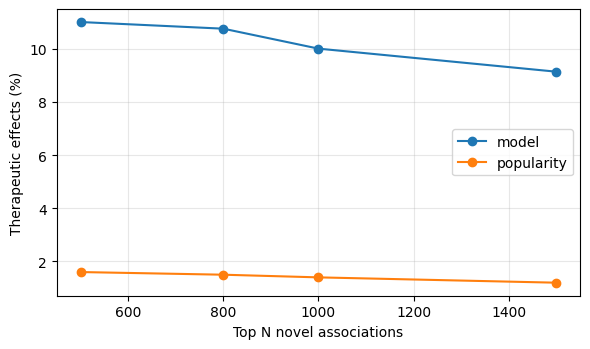

In [37]:
# Same curve for the popularity baseline. This is the plot to put in the paper.
pop_global = top_pairs(pop, Y_arr, drug_ids, disease_ids, n=GLOBAL_N, per_drug=False)
pop_global_res = verify(pop_global, drug2mesh, dis2mesh, drug_names)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 3.6))
for label, frame in [
    ("model", prec_df),
    ("popularity", precision_at_n(pop_global_res)),
]:
    ax.plot(frame.N, frame.precision * 100, marker="o", label=label)
ax.set_xlabel("Top N novel associations")
ax.set_ylabel("Therapeutic effects (%)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Popularity baseline — the check that matters most

Rank the same zero entries by `row-degree × column-degree` and nothing else.

If this scores close to your model, the top-N is reporting **dataset density, not biology**.
One cell, and it is the first thing a sharp reviewer will wonder about. Run DRIMC and
NRLMF through the same `top_pairs` → `verify` → `hit_rates` chain if you have their
score matrices.

In [38]:
pop = (Y_arr.sum(1)[:, None] * Y_arr.sum(0)[None, :]).astype(float)
pop += np.random.default_rng(0).uniform(0, 1e-6, pop.shape)  # break degree ties

pop_pred = top_pairs(pop, Y_arr, drug_ids, disease_ids, n=TOP_N, per_drug=True)
pop_res = verify(pop_pred, drug2mesh, dis2mesh, drug_names)

# Same model, three mapping tiers -- shows whether the looser mappings carry
# the result. Plus the popularity baseline under the recommended tier.
comparison = pd.concat(
    [
        hit_rates(verify(pred, drug2mesh, m, drug_names, db2ind)).assign(
            method=f"model ({t})"
        )
        for t, m in dis_tiers.items()
    ]
    + [hit_rates(pop_res).assign(method="popularity")],
    ignore_index=True,
)

comparison.pivot(index="K", columns="method", values="hit_rate").style.format("{:.1%}")

method,model (inclusive),model (recommended),model (strict),popularity
K,,,,
1,13.0%,13.0%,12.7%,0.0%
3,25.5%,25.5%,24.4%,0.0%
5,34.3%,34.3%,32.7%,0.3%
10,44.3%,44.3%,42.1%,1.9%


## 8. Export for the manuscript

In [79]:
DATASET = "cdataset"       # <- label for the output filenames
OUT_DIR = os.path.join(ROOT, "outputs", "verified")
os.makedirs(OUT_DIR, exist_ok=True)
stem = os.path.join(OUT_DIR, f"{DATASET}_top{TOP_N}")

res.to_csv(f"{stem}_perdrug.tsv", sep="\t", index=False)
res_global.to_csv(f"{stem}_global.tsv", sep="\t", index=False)
comparison.to_csv(f"{stem}_hitrates.tsv", sep="\t", index=False)

with open(f"{stem}.provenance.txt", "w") as fh:
    fh.write(f"generated : {time.strftime('%Y-%m-%d %H:%M:%S %Z')}\n")
    fh.write(f"dataset   : {DATASET}   top-N per drug: {TOP_N}\n")
    fh.write(f"matrix    : {Y_arr.shape[0]} drugs x {Y_arr.shape[1]} diseases, "
             f"{int(Y_arr.sum())} known\n")
    fh.write(f"drugs     : {res.drug_id.nunique()}  "
             f"unmapped: {res[~res.mapped].drug_id.nunique()}  "
             f"eligible: {len(ELIGIBLE)}\n")
    fh.write(f"diseases  : {dis_report['resolved']}/{dis_report['total']} "
             f"resolved {dis_report['via']}\n")
    fh.write(f"chembl    : {USE_CHEMBL}\n\n")
    p = os.path.join(vp.CACHE, "PROVENANCE.txt")
    if os.path.exists(p):
        fh.write(open(p).read())

print("wrote", stem + "_perdrug.tsv")

wrote /Users/sijianfan/projects/BiSSGL/outputs/verified/cdataset_top10_perdrug.tsv


### A table you could paste into the paper

Only confirmed pairs, formatted like DRIMC's Table 4.

In [81]:
confirmed = (res[res.ctd_therapeutic]
             .sort_values(["drug_id", "rank_pos"])
             [["drug_name", "drug_id", "ctd_disease_name", "mesh_disease",
               "rank_pos", "score", "ctd_pmids"]])
print(f"{len(confirmed)} confirmed pairs ({len(confirmed)/len(res):.1%} of predictions)")
confirmed.head(10)

249 confirmed pairs (3.8% of predictions)


,drug_name,drug_id,ctd_disease_name,mesh_disease,rank_pos,score,ctd_pmids
21,Cyclosporine,DB00091,"Purpura, Thrombocytopenic, Idiopathic",D016553,2,0.047856,11472356
73,Ascorbic acid,DB00126,Obesity,D009765,4,0.079839,17217161
296,Baclofen,DB00181,Alcoholism,D000437,7,0.075535,29945230
316,Lorazepam,DB00186,Schizophrenia,D012559,7,0.110927,12095078|9754850
327,Esmolol,DB00187,"Arrhythmias, Cardiac",D001145,8,0.040542,12885410
332,Bortezomib,DB00188,"Leukemia, Myeloid, Acute",D015470,3,0.013837,18166786|20471514
344,Carbidopa,DB00190,Parkinsonian Disorders,D020734,5,0.079523,23206800|2611764|4834974
377,Betaxolol,DB00195,"Arrhythmias, Cardiac",D001145,8,0.054913,2883336
433,Reserpine,DB00206,"Arrhythmias, Cardiac",D001145,4,0.025881,4990592
601,Cladribine,DB00242,"Leukemia, Myeloid, Acute",D015470,2,0.118839,7948311|7949097


### 8b. Case-study table (DRIMC Table 4 format)

DRIMC's Table 4 lists each selected drug's **entire** top-5 and marks the
CTD-verified ones with a superscript. Keeping the misses is the point: it shows
the denominator, so a reader can see whether three hits came out of five
predictions or out of fifty.

`score` is the model's predicted association probability --- `prob_full` passed
through unchanged, i.e. `expit(U @ est_A @ est_B.T @ V.T)` restricted to entries
that were zero in the training matrix.

**On choosing the drugs:** DRIMC used "six randomly selected drugs". Picking the
drugs with the most confirmed hits would make the table look better and mean
nothing --- so the default here is a seeded random sample, and any other choice
should be stated in the caption.

In [100]:
def disease_label(did):
    """Display name for a disease id, verified or not."""
    c = dis2mesh.get(did)
    if c and c in DIS_LABELS:
        return DIS_LABELS[c]
    t = OMIM_NAMES.get(re.sub(r"^[A-Za-z]+", "", str(did)))
    if isinstance(t, list) and t:
        return t[0].title()
    return str(did)


def case_study(res_frame, drugs=None, k=5, n_drugs=6, seed=0,
               select="random"):
    """Every top-k prediction for selected drugs, hits AND misses.

    select : 'random'   -- seeded sample of eligible drugs (DRIMC's choice)
             'hits'     -- drugs with the most verified pairs. Cherry-picking;
                           only defensible if the caption says so.
    """
    df = res_frame[res_frame.rank_pos <= k].copy()
    df = df[df.drug_id.isin(ELIGIBLE)]

    if drugs is None:
        if select == "hits":
            order = (df.groupby("drug_id").ctd_therapeutic.sum()
                       .sort_values(ascending=False))
            drugs = list(order.index[:n_drugs])
        else:
            rng = np.random.default_rng(seed)
            pool = sorted(df.drug_id.unique())
            drugs = list(rng.choice(pool, size=min(n_drugs, len(pool)),
                                    replace=False))

    out = df[df.drug_id.isin(drugs)].copy()
    out["disease"] = out.disease_id.map(disease_label)
    out["verified"] = out.ctd_therapeutic
    return (out.sort_values(["drug_id", "rank_pos"])
               [["drug_name", "drug_id", "rank_pos", "disease",
                 "mesh_disease", "score", "verified", "ctd_pmids"]]
               .reset_index(drop=True))


cases = case_study(per_method_res["BVSIMC"], k=5, n_drugs=6, select="hits")
print(f"{int(cases.verified.sum())}/{len(cases)} of the shown predictions are "
      f"CTD-verified")
cases

21/30 of the shown predictions are CTD-verified


,drug_name,drug_id,rank_pos,disease,mesh_disease,score,verified,ctd_pmids
0,Mitomycin,DB00305,1,Breast Neoplasms,D001943,0.172818,True,1906166|2829807|3932789|6810311|7491579|848355...
1,Mitomycin,DB00305,2,Prostatic Neoplasms,D011471,0.131934,True,6340628
2,Mitomycin,DB00305,3,Esophageal Neoplasms,D004938,0.129071,True,1519930
3,Mitomycin,DB00305,4,"Carcinoma, Renal Cell",D002292,0.100599,False,
4,Mitomycin,DB00305,5,Wilms Tumor,D009396,0.099342,False,
5,Zoledronic acid,DB00399,1,Osteoporosis,D010024,0.357159,True,17882678
6,Zoledronic acid,DB00399,2,Breast Neoplasms,D001943,0.187814,True,16096432|18695136
7,Zoledronic acid,DB00399,3,Hodgkin Disease,D006689,0.133332,False,
8,Zoledronic acid,DB00399,4,"Carcinoma, Renal Cell",D002292,0.084530,True,17070308|18507039
9,Zoledronic acid,DB00399,5,"Hyperphosphatemia, Polyuria, and Seizures",C565494,0.043375,False,


In [102]:
def case_study_latex(cases, label="tab:ctd_cases"):
    """DRIMC Table 4 layout: one row per drug, diseases in one cell,
    superscript a on the verified ones."""
    lines = [r"\begin{table}[htbp]", r"\centering",
             r"\caption{\textbf{Top-5 predictions for six selected "
             r"drugs.} Diseases are listed in decreasing predicted probability. "
             r"$^{a}$ marks pairs supported by a curated CTD therapeutic "
             r"record absent from the training matrix.}",
             rf"\label{{{label}}}",
             r"\begin{tabular}{p{0.28\textwidth}p{0.62\textwidth}}",
             r"\toprule", r"Drug & Predicted indications \\", r"\midrule"]
    for did, g in cases.groupby("drug_id", sort=False):
        name = g.drug_name.iloc[0] or did
        items = []
        for r in g.itertuples(index=False):
            mark = "$^{a}$" if r.verified else ""
            items.append(f"{r.disease} ({r.mesh_disease}){mark}")
        lines.append(f"{name} ({did}) & " + "; ".join(items) + r" \\")
    lines += [r"\bottomrule", r"\end{tabular}", r"\end{table}"]
    return "\n".join(lines)


print(case_study_latex(cases))

\begin{table}[htbp]
\centering
\caption{\textbf{Top-5 predictions for six selected drugs.} Diseases are listed in decreasing predicted probability. $^{a}$ marks pairs supported by a curated CTD therapeutic record absent from the training matrix.}
\label{tab:ctd_cases}
\begin{tabular}{p{0.28\textwidth}p{0.62\textwidth}}
\toprule
Drug & Predicted indications \\
\midrule
Mitomycin (DB00305) & Breast Neoplasms (D001943)$^{a}$; Prostatic Neoplasms (D011471)$^{a}$; Esophageal Neoplasms (D004938)$^{a}$; Carcinoma, Renal Cell (D002292); Wilms Tumor (D009396) \\
Zoledronic acid (DB00399) & Osteoporosis (D010024)$^{a}$; Breast Neoplasms (D001943)$^{a}$; Hodgkin Disease (D006689); Carcinoma, Renal Cell (D002292)$^{a}$; Hyperphosphatemia, Polyuria, and Seizures (C565494) \\
Vincristine (DB00541) & Testicular Germ Cell Tumor (C563236); Purpura, Thrombocytopenic, Idiopathic (D016553)$^{a}$; Leukemia, Lymphocytic, Chronic, B-Cell (D015451); Leukemia, Myelogenous, Chronic, BCR-ABL Positive (D015464)$^

### Optional — PubMed triage for the unconfirmed ones

For the discussion section only. Co-occurrence is **not** confirmation; label these
pairs as literature-supported, never as validated.

In [ ]:
RUN_PUBMED = False

if RUN_PUBMED:
    todo = res[(~res.ctd_therapeutic) & res.mapped].head(30)
    lit = []
    for r in todo.itertuples(index=False):
        cnt, pmids = vp.pubmed_hits(r.drug_name, r.disease_id,
                                    api_key=os.environ.get("NCBI_API_KEY"))
        lit.append({"drug_name": r.drug_name, "disease_id": r.disease_id,
                    "rank": r.rank_pos, "pubmed_count": cnt, "pmids": pmids})
    display(pd.DataFrame(lit).sort_values("pubmed_count", ascending=False))

---

### Before you quote a number

1. **Use the per-drug table for hit rates.** The global top-10 is a nice illustrative
   table (it's what DRIMC's Table 4 looks like) but it is not a rate — check how many
   distinct drugs it actually covers before describing it as a result.
2. **Unmapped drugs are excluded, not counted as misses.** Section 6 prints the count.
3. **Report strict and relaxed separately.**
4. **PubMed co-occurrence is not confirmation.**
5. **Say which CTD release** — it updates monthly; the provenance file has it.
6. **Show the popularity baseline.** Three rows — popularity / DRIMC / yours, one
   protocol — beats a hand-annotated top-10 by a wide margin.

---

## 9. All methods, one protocol

Every method goes through the **identical** pipeline — same `Y`, same drug and disease
mappings, same CTD release, same `ELIGIBLE` denominator. The only thing that varies is
`prob_full`. That is what makes the comparison fair, and it is why the mapping work
earlier was worth doing.

`popularity` is not a competing method — it is the floor. Any method that fails to clear
it is reporting dataset density rather than biology.

In [42]:
# Display name -> score matrix, in the order they should appear.
METHODS = {
    "BVSIMC": prob_full_bissgl,
    "SGIMC": prob_full_sgimc,
    "IMC": prob_full_imc,
    "DRIMC": prob_full_drimc,
    "NRLMF": prob_full_nrlmf,
}

# The popularity floor is computed and exported but not plotted. Flip to True to
# put it back into both tables and both panels.
SHOW_POPULARITY = False

ALL = dict(METHODS)
if SHOW_POPULARITY:
    ALL["Popularity"] = pop

for name, P in ALL.items():
    assert P.shape == Y_arr.shape, (name, P.shape, Y_arr.shape)
print(f"{len(ALL)} score matrices, all {Y_arr.shape}")

5 score matrices, all (658, 409)


In [43]:
def evaluate(name, P):
    """Run one score matrix through the whole protocol."""
    pd_pairs = top_pairs(P, Y_arr, drug_ids, disease_ids, n=TOP_N, per_drug=True)
    gl_pairs = top_pairs(P, Y_arr, drug_ids, disease_ids, n=GLOBAL_N, per_drug=False)
    r_drug = verify(pd_pairs, drug2mesh, dis2mesh, drug_names)
    r_pair = verify(gl_pairs, drug2mesh, dis2mesh, drug_names)
    return (
        hit_rates(r_drug).assign(method=name),
        precision_at_n(r_pair).assign(method=name),
        r_drug,
    )


hits_all, prec_all, per_method_res = [], [], {}
for name, P in ALL.items():
    h, p, r = evaluate(name, P)
    hits_all.append(h)
    prec_all.append(p)
    per_method_res[name] = r
    print(f"  {name:<12} {int(r.ctd_therapeutic.sum())} confirmed pairs")

hits_all = pd.concat(hits_all, ignore_index=True)
prec_all = pd.concat(prec_all, ignore_index=True)
ORDER = list(ALL)

  BVSIMC       249 confirmed pairs
  SGIMC        230 confirmed pairs
  IMC          218 confirmed pairs
  DRIMC        219 confirmed pairs
  NRLMF        43 confirmed pairs


### Table 1 — per-drug hit rate (denominator: eligible drugs)

In [44]:
t1 = hits_all.pivot(index="method", columns="K", values="hit_rate").reindex(ORDER)
t1.columns = [f"top-{k}" for k in t1.columns]
display(t1.style.format("{:.1%}"))

,top-1,top-3,top-5,top-10
method,,,,
BVSIMC,13.0%,25.5%,34.3%,44.3%
SGIMC,11.9%,23.5%,28.8%,38.2%
IMC,10.0%,24.1%,29.1%,38.2%
DRIMC,6.9%,18.3%,27.1%,39.3%
NRLMF,1.4%,3.6%,4.4%,7.8%


### Table 2 — precision@N over the global pair ranking

In [45]:
t2 = prec_all.pivot(index="method", columns="N", values="precision").reindex(ORDER)
t2.columns = [f"@{n}" for n in t2.columns]
display(t2.style.format("{:.1%}"))

,@500,@800,@1000,@1500
method,,,,
BVSIMC,11.0%,10.8%,10.0%,9.1%
SGIMC,8.4%,8.0%,7.3%,7.4%
IMC,4.6%,5.4%,5.8%,5.7%
DRIMC,5.6%,5.8%,6.5%,6.8%
NRLMF,1.4%,1.2%,1.4%,1.3%


### Figure — grouped bars, both panels

Colours are exactly the ones used elsewhere in the manuscript.

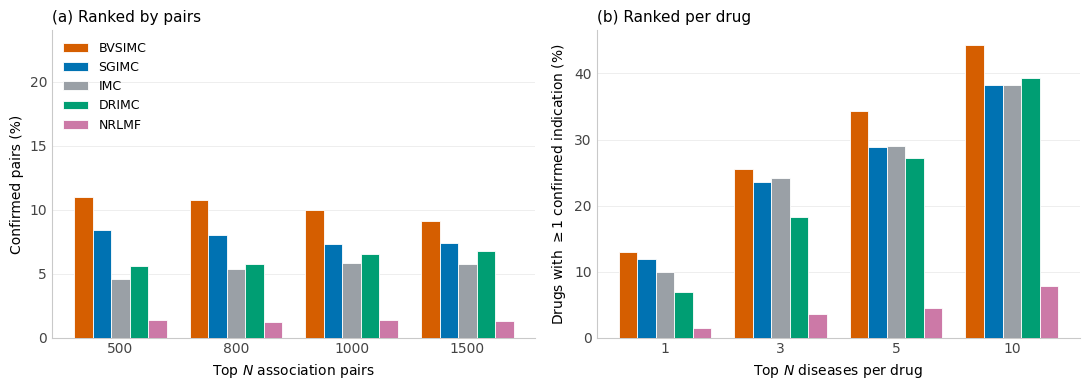

saved /Users/sijianfan/projects/BiSSGL/outputs/figures/realAnalysis/cdataset/fold_cv/comb/cdataset_verification.pdf
saved folder /Users/sijianfan/projects/BiSSGL/outputs/figures/realAnalysis/cdataset/fold_cv/comb


In [78]:
import matplotlib.pyplot as plt
import numpy as np

# Manuscript palette -- keep in sync with the other figures.
STYLE = {
    "bvsimc": dict(color="#D55E00", marker="o"),  # vermillion - proposed method
    "sgimc": dict(color="#0072B2", marker="s"),  # blue
    "drimc": dict(color="#009E73", marker="^"),  # bluish green
    "nrlmf": dict(color="#CC79A7", marker="D"),  # reddish purple
    "imc": dict(color="#9AA0A6", marker="v"),  # neutral grey - baseline
    "popularity": dict(color="#BFBFBF", marker="x"),
}
PREC_NS = [500, 800, 1000, 1500]  # matches DRIMC Fig. 6
ANNOTATE = False  # per-bar value labels; the tables carry them


def grouped_bars(ax, frame, xcol, ycol, xticklabels, methods):
    x = np.arange(len(xticklabels))
    w = 0.8 / len(methods)
    for i, m in enumerate(methods):
        d = (
            frame[frame.method == m]
            .set_index(xcol)
            .reindex([int(v) for v in xticklabels])[ycol]
            .values
            * 100
        )
        off = (i - (len(methods) - 1) / 2) * w
        bars = ax.bar(
            x + off,
            d,
            w,
            label=m,
            zorder=3,
            color=STYLE[m.lower()]["color"],
            edgecolor="white",
            linewidth=0.6,
        )
        if ANNOTATE:
            ax.bar_label(bars, fmt="%.0f", fontsize=7, padding=1, color="#444444")
    ax.set_xticks(x)
    ax.set_xticklabels(xticklabels)
    return ax


fig, axes = plt.subplots(1, 2, figsize=(11, 4))

KS = sorted(hits_all.K.unique())
grouped_bars(axes[1], hits_all, "K", "hit_rate", KS, ORDER)
axes[1].set_xlabel("Top $N$ diseases per drug")
axes[1].set_ylabel("Drugs with $\geq$1 confirmed indication (%)")
axes[1].set_title("(b) Ranked per drug", loc="left", fontsize=11)

grouped_bars(axes[0], prec_all, "N", "precision", PREC_NS, ORDER)
axes[0].set_xlabel("Top $N$ association pairs")
axes[0].set_ylabel("Confirmed pairs (%)")
axes[0].set_title("(a) Ranked by pairs", loc="left", fontsize=11)
axes[0].set_ylim(top=24)

for ax in axes:
    ax.grid(axis="y", alpha=0.25, lw=0.6)
    ax.set_axisbelow(True)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    ax.spines["left"].set_color("#c9c9c9")
    ax.spines["bottom"].set_color("#c9c9c9")
    ax.tick_params(colors="#444444", length=0)
    ax.set_ylim(bottom=0)

axes[0].legend(frameon=False, fontsize=9, loc="upper left")
plt.tight_layout()
for ext, kw in (("pdf", {}), ("png", {"dpi": 300})):
    fig.savefig(
        os.path.join(FIG_DIR, f"{DATASET}_verification.{ext}"),
        bbox_inches="tight",
        **kw,
    )
plt.show()
print("saved", os.path.join(FIG_DIR, f"{DATASET}_verification.pdf"))
print("saved folder", os.path.join(FIG_DIR))

### Export

In [57]:
hits_all.to_csv(
    os.path.join(TAB_DIR, f"{DATASET}_verification_per_drug.tsv"), sep="\t", index=False
)
prec_all.to_csv(
    os.path.join(TAB_DIR, f"{DATASET}_verification_by_pairs.tsv"), sep="\t", index=False
)

print(
    t1.to_latex(
        float_format=lambda v: f"{v*100:.1f}",
        caption=(
            f"Per-drug hit rate on {DATASET} "
            f"(n={len(ELIGIBLE)} eligible drugs), verified against "
            f"CTD curated therapeutic records."
        ),
        label=f"tab:{DATASET}_verification_per_drug",
    )
)

print(
    t2.to_latex(
        float_format=lambda v: f"{v*100:.1f}",
        caption=(
            f"Top N precision on {DATASET} "
            f"(n={len(ELIGIBLE)} eligible drugs), verified against "
            f"CTD curated therapeutic records."
        ),
        label=f"tab:{DATASET}_verification_by_pairs",
    )
)

\begin{table}
\centering
\caption{Per-drug hit rate on cdataset (n=361 eligible drugs), verified against CTD curated therapeutic records.}
\label{tab:cdataset_verification_per_drug}
\begin{tabular}{lrrrr}
\toprule
{} &  top-1 &  top-3 &  top-5 &  top-10 \\
method &        &        &        &         \\
\midrule
BVSIMC &   13.0 &   25.5 &   34.3 &    44.3 \\
SGIMC  &   11.9 &   23.5 &   28.8 &    38.2 \\
IMC    &   10.0 &   24.1 &   29.1 &    38.2 \\
DRIMC  &    6.9 &   18.3 &   27.1 &    39.3 \\
NRLMF  &    1.4 &    3.6 &    4.4 &     7.8 \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}
\centering
\caption{Top N precision on cdataset (n=361 eligible drugs), verified against CTD curated therapeutic records.}
\label{tab:cdataset_verification_by_pairs}
\begin{tabular}{lrrrr}
\toprule
{} &  @500 &  @800 &  @1000 &  @1500 \\
method &       &       &        &        \\
\midrule
BVSIMC &  11.0 &  10.8 &   10.0 &    9.1 \\
SGIMC  &   8.4 &   8.0 &    7.3 &    7.4 \\
IMC    &   4.6 &   5

/var/folders/9n/bp97cgrn0n11p1dftj7qqgbh0000gn/T/ipykernel_20203/2839262351.py:9: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  t1.to_latex(
/var/folders/9n/bp97cgrn0n11p1dftj7qqgbh0000gn/T/ipykernel_20203/2839262351.py:21: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  t2.to_latex(


---

### Reporting checklist

- [ ] `ELIG_STATS` — eligible count, plus the unmapped / no-record split
- [ ] mapping coverage — 657/658 drugs, N/409 diseases, and by which route
- [ ] CTD release date — in the `.provenance.txt` sidecar
- [ ] **both** denominators (`eligible` and `all`) for Table 1
- [ ] which disease-mapping tier, and that strict/recommended/inclusive agree
- [ ] the popularity floor — not plotted, but it is in `*_hitrates_all.tsv` when
      `SHOW_POPULARITY=True`, and it is the first thing a referee will ask for